In [1]:
import math
import torch
import torchaudio
import numpy as np
import matplotlib.pyplot as plt
import torchaudio.transforms as T
from pathlib import Path
import os
import pandas as pd

# read in the dataset
FSD50K = Path('./data')
audio = FSD50K /'FSD50K.dev_audio'

# Audio Setup for TorchAudio
CLIP_TIME    = 5.94   # Seconds 
SAMPLE_RATE  = 22050  # Half of native
SAMPLE_COUNT = int(SAMPLE_RATE * CLIP_TIME)
HOP_LENGTH   = 256    # Step between windows
MEL_N        = 128    # Mel filter banks
FFT_N        = 1024   # FFT window
F_MIN        = 100    # Hz
F_MAX        = 10000  # Hz
DB_MAX       = 80.0   # DB

# Expected time frames for a 5-second clip
FRAME_COUNT = math.ceil(SAMPLE_COUNT / HOP_LENGTH)
print(f"Target shape per clip: (1, {MEL_N}, {FRAME_COUNT})")

Target shape per clip: (1, 128, 512)


In [2]:
# Pick the first wav file in the dev audio folder
wav_files = sorted(audio.glob("*.wav"))
test_file = wav_files[0]
waveform, sr = torchaudio.load(test_file)

print(f"File        : {test_file.name}")
print(f"Sample rate : {sr} Hz")
print(f"Channels    : {waveform.shape[0]}")
print(f"Samples     : {waveform.shape[1]}")
print(f"Duration    : {waveform.shape[1] / sr:.2f} s")

File        : 10000.wav
Sample rate : 44100 Hz
Channels    : 1
Samples     : 18856
Duration    : 0.43 s


### Make dataframe

In [3]:
df                      = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'dev.csv')
df_train                = df[df['split'] == 'train'].reset_index(drop=True)
df_train['labels']   = df_train['labels'].apply(lambda x: x.split(','))
df_train['audio_path']  = df_train['fname'].apply(lambda x: os.path.join(audio, f'{x}.wav'))
print(df_train['audio_path'])

df_eval = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'eval.csv')
df_eval['labels']     = df_eval['labels'].apply(lambda x: x.split(','))
df_eval['audio_path'] = df_eval['fname'].apply(lambda x: os.path.join(FSD50K / 'FSD50K.eval_audio', f'{x}.wav'))

0         data\FSD50K.dev_audio\64760.wav
1         data\FSD50K.dev_audio\16399.wav
2         data\FSD50K.dev_audio\16401.wav
3         data\FSD50K.dev_audio\16402.wav
4         data\FSD50K.dev_audio\16404.wav
                       ...               
36791    data\FSD50K.dev_audio\102863.wav
36792    data\FSD50K.dev_audio\389607.wav
36793     data\FSD50K.dev_audio\90091.wav
36794    data\FSD50K.dev_audio\244718.wav
36795     data\FSD50K.dev_audio\24061.wav
Name: audio_path, Length: 36796, dtype: object


In [4]:
vocabulary = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'vocabulary.csv')
vocabulary.columns = ["index", "label", "mid"]
vocabulary             = pd.read_csv(FSD50K / 'FSD50K.ground_truth' / 'vocabulary.csv')
vocabulary.columns     = ["index", "label", "mid"]
label_to_idx           = {label: idx for idx, label in enumerate(vocabulary['label'].unique())}
num_classes            = len(label_to_idx)

print(f"Train clips: {len(df_train)}")
print(f"Num classes: {num_classes}")

Train clips: 36796
Num classes: 199


### make function for torch dataloader:

In [5]:
# class dataset function
from torch.utils.data import Dataset, DataLoader
import torch

class FSD50KDataset(Dataset):
    def __init__(self, df, label_to_idx, num_classes, split='train'):
        self.df           = df.reset_index(drop=True)
        self.num_classes  = num_classes
        self.preprocessed = Path(f"preprocessed/{split}")
        self.split        = split

        # Precompute all label vectors once at init
        self.labels = torch.zeros(len(self.df), num_classes)
        for i, row in self.df.iterrows():
            for lbl in row['labels']:
                lbl = lbl.strip()
                if lbl in label_to_idx:
                    self.labels[i, label_to_idx[lbl]] = 1.0
        self.fnames = self.df['fname'].tolist()  # in __init__
        
    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        spec = torch.load(self.preprocessed / f"{self.fnames[idx]}.pt")
        #if self.split == 'train':
        #    spec = augment_spec(spec)  # calls the free function
        return spec, self.labels[idx]

In [6]:
#classifier
import torch.nn as nn
class AudioCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1), nn.BatchNorm2d(32), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.BatchNorm2d(64), nn.ReLU(True), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.BatchNorm2d(128), nn.ReLU(True), nn.AdaptiveAvgPool2d((4, 4)),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

In [7]:
#fraction and data laoder
# ── Small fraction for quick test ─────────────────────────────────────────────
fraction    = 1
df_small    = df_train.sample(frac=fraction, random_state=42).reset_index(drop=True)
df_val      = df[df['split'] == 'val'].reset_index(drop=True)
df_val['labels']     = df_val['labels'].apply(lambda x: x.split(',') if isinstance(x, str) else x)
df_val['audio_path'] = df_val['fname'].apply(lambda x: os.path.join(audio, f'{x}.wav'))
df_val_small = df_val.sample(frac=fraction, random_state=42).reset_index(drop=True)

train_dataset = FSD50KDataset(df_small,     label_to_idx, num_classes, split='train')
val_dataset   = FSD50KDataset(df_val_small, label_to_idx, num_classes, split='val')
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader    = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=0)

In [ ]:

# ── Training setup ─────────────────────────────────────────────────────────────
from tqdm import tqdm
epochs    = 30
device    = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model     = AudioCNN(num_classes=num_classes).to(device)
criterion = nn.BCEWithLogitsLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
#epochs without restarts
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

In [9]:
# ── Training loop ──────────────────────────────────────────────────────────────
def train_one_epoch(loader, epoch_bar):
    model.train()
    total_loss = 0
    with tqdm(loader, desc="  Train", leave=False, unit="batch") as batch_bar:
        for specs, labels in batch_bar:
            specs, labels = specs.to(device), labels.to(device)
            optimizer.zero_grad()
            loss = criterion(model(specs), labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    scheduler.step()
    return total_loss / len(loader)

def evaluate(loader):
    model.eval()
    total_loss = 0
    with torch.no_grad():
        with tqdm(loader, desc="    Val", leave=False, unit="batch") as batch_bar:
            for specs, labels in batch_bar:
                specs, labels = specs.to(device), labels.to(device)
                loss = criterion(model(specs), labels)
                total_loss += loss.item()
                batch_bar.set_postfix(loss=f"{loss.item():.4f}")
    return total_loss / len(loader)
"""
# ── Epoch loop ─────────────────────────────────────────────────────────────────
with tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:
    for epoch in epoch_bar:
        train_loss = train_one_epoch(train_loader, epoch_bar)
        val_loss   = evaluate(val_loader)
        lr         = scheduler.get_last_lr()[0]
        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")
        tqdm.write(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {lr:.2e}")
"""

'\n# ── Epoch loop ─────────────────────────────────────────────────────────────────\nwith tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:\n    for epoch in epoch_bar:\n        train_loss = train_one_epoch(train_loader, epoch_bar)\n        val_loss   = evaluate(val_loader)\n        lr         = scheduler.get_last_lr()[0]\n        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", lr=f"{lr:.2e}")\n        tqdm.write(f"Epoch {epoch+1:02d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | LR: {lr:.2e}")\n'

In [10]:
from sklearn.metrics import (accuracy_score, hamming_loss, f1_score, 
                              average_precision_score, roc_auc_score,
                              precision_recall_curve, auc)
from scipy.stats import norm

def evaluate_metrics(loader, threshold=0.3):
    model.eval()
    all_preds, all_labels_list, all_probs_list = [], [], []
    with torch.no_grad():
        for specs, labels in loader:
            probs = torch.sigmoid(model(specs.to(device))).cpu()
            all_preds.append((probs > threshold).float())
            all_labels_list.append(labels)
            all_probs_list.append(probs)
    all_preds  = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels_list).numpy()
    all_probs  = torch.cat(all_probs_list).numpy()
    return all_preds, all_labels, all_probs

def tune_thresholds(all_labels, all_probs):
    best_thresholds = []
    for i in range(all_labels.shape[1]):
        best_t, best_f1 = 0.5, 0.0
        for t in np.arange(0.1, 0.9, 0.05):
            preds = (all_probs[:, i] > t).astype(float)
            f1 = f1_score(all_labels[:, i], preds, zero_division=0)
            if f1 > best_f1:
                best_f1, best_t = f1, t
        best_thresholds.append(best_t)
    return np.array(best_thresholds)

def compute_all_metrics(all_labels, all_probs):
    # Tuned F1
    thresholds     = tune_thresholds(all_labels, all_probs)
    tuned_preds    = (all_probs > thresholds).astype(float)
    f1_micro       = f1_score(all_labels, tuned_preds, average='micro', zero_division=0)
    f1_macro       = f1_score(all_labels, tuned_preds, average='macro', zero_division=0)

    # mAP
    map_score      = average_precision_score(all_labels, all_probs, average='macro')

    # d'
    valid          = (all_labels.sum(axis=0) > 0) & (all_labels.sum(axis=0) < len(all_labels))
    roc_auc        = roc_auc_score(all_labels[:, valid], all_probs[:, valid], average='macro')
    dp             = np.sqrt(2) * norm.ppf(roc_auc)

    # lωlrap
    has_pos        = all_labels.sum(axis=1) > 0
    labels_pos     = all_labels[has_pos]
    probs_pos      = all_probs[has_pos]
    per_sample_ap, per_sample_w = [], []
    for i in range(len(labels_pos)):
        pos_cls    = np.where(labels_pos[i] > 0)[0]
        ranked     = np.argsort(-probs_pos[i])
        precisions, num_correct = [], 0
        for rank, cls in enumerate(ranked):
            if cls in pos_cls:
                num_correct += 1
                precisions.append(num_correct / (rank + 1))
            if num_correct == len(pos_cls):
                break
        per_sample_ap.append(np.mean(precisions))
        per_sample_w.append(len(pos_cls))
    lwlrap_score   = np.sum(np.array(per_sample_w) * np.array(per_sample_ap)) / np.sum(per_sample_w)

    # mAP 6 families
    families       = ['Music', 'Human_voice', 'Domestic_sounds_and_home_sounds',
                      'Animal', 'Vehicle', 'Natural_sounds']
    family_idx     = [label_to_idx[f] for f in families if f in label_to_idx]
    map_families   = average_precision_score(all_labels[:, family_idx],
                                             all_probs[:, family_idx], average='macro')

    print(f"F1 Micro (tuned): {f1_micro:.4f}  |  F1 Macro (tuned): {f1_macro:.4f}")
    print(f"mAP:    {map_score:.3f}  (paper CRNN: 0.417, VGG-like: 0.434)")
    print(f"d':     {dp:.3f}         (paper CRNN: 2.068, VGG-like: 2.167)")
    print(f"lωlrap: {lwlrap_score:.3f}  (paper CRNN: 0.519, VGG-like: 0.514)")
    print(f"mAP (6 families): {map_families:.4f}")

    return all_preds, all_labels, all_probs

In [11]:
best_map   = 0.0
no_improve = 0
patience   = 5
history = {'train_loss': [], 'val_loss': [], 'map': []}


with tqdm(range(epochs), desc="Epochs", unit="epoch") as epoch_bar:
    for epoch in epoch_bar:
        train_loss = train_one_epoch(train_loader, epoch_bar)
        val_loss   = evaluate(val_loader)
        # remove extra scheduler.step() — already in train_one_epoch

        _, labels_np, probs_np = evaluate_metrics(val_loader)
        current_map = average_precision_score(labels_np, probs_np, average='macro')
        epoch_bar.set_postfix(train=f"{train_loss:.4f}", val=f"{val_loss:.4f}", map=f"{current_map:.4f}")
        tqdm.write(f"Epoch {epoch+1:02d} | Train: {train_loss:.4f} | Val: {val_loss:.4f} | mAP: {current_map:.4f}")

        if current_map > best_map:
            best_map   = current_map
            no_improve = 0
            torch.save(model.state_dict(), 'best_unhelped_model.pt')
            tqdm.write(f"  → New best mAP {current_map:.4f} saved at epoch {epoch+1}")
        else:
            no_improve += 1

        if no_improve >= patience:
            tqdm.write(f"Early stopping at epoch {epoch+1}, best mAP: {best_map:.4f}")
            break

model.load_state_dict(torch.load('best_unhelped_model.pt'))

Epochs:   3%|▎         | 1/30 [46:05<22:16:26, 2765.04s/epoch, map=0.0804, train=0.0706, val=0.0606]

Epoch 01 | Train: 0.0706 | Val: 0.0606 | mAP: 0.0804
  → New best mAP 0.0804 saved at epoch 1


Epochs:   7%|▋         | 2/30 [1:33:26<21:51:26, 2810.23s/epoch, map=0.1408, train=0.0451, val=0.0539]

Epoch 02 | Train: 0.0451 | Val: 0.0539 | mAP: 0.1408
  → New best mAP 0.1408 saved at epoch 2


Epochs:  10%|█         | 3/30 [2:14:11<19:49:23, 2643.11s/epoch, map=0.1712, train=0.0401, val=0.0517]

...

Epochs:  97%|█████████▋| 29/30 [19:12:50<38:16, 2296.14s/epoch, map=0.3505, train=0.0243, val=0.0417]  

Epoch 29 | Train: 0.0243 | Val: 0.0417 | mAP: 0.3505
  → New best mAP 0.3505 saved at epoch 29


Epochs: 100%|██████████| 30/30 [19:49:13<00:00, 2378.46s/epoch, map=0.3517, train=0.0243, val=0.0416]

Epoch 30 | Train: 0.0243 | Val: 0.0416 | mAP: 0.3517
  → New best mAP 0.3517 saved at epoch 30


<All keys matched successfully>

In [14]:
# Reload the saved model and evaluate
model = AudioCNN(num_classes=num_classes).to(device)
model.load_state_dict(torch.load('best_unhelped_model.pt'))
model.eval()

# Get final metrics
all_preds, all_labels, all_probs = evaluate_metrics(val_loader)
compute_all_metrics(all_labels, all_probs);

F1 Micro (tuned): 0.5449  |  F1 Macro (tuned): 0.3784
mAP:    0.352  (paper CRNN: 0.417, VGG-like: 0.434)
d':     2.146         (paper CRNN: 2.068, VGG-like: 2.167)
lωlrap: 0.636  (paper CRNN: 0.519, VGG-like: 0.514)
mAP (6 families): 0.6460


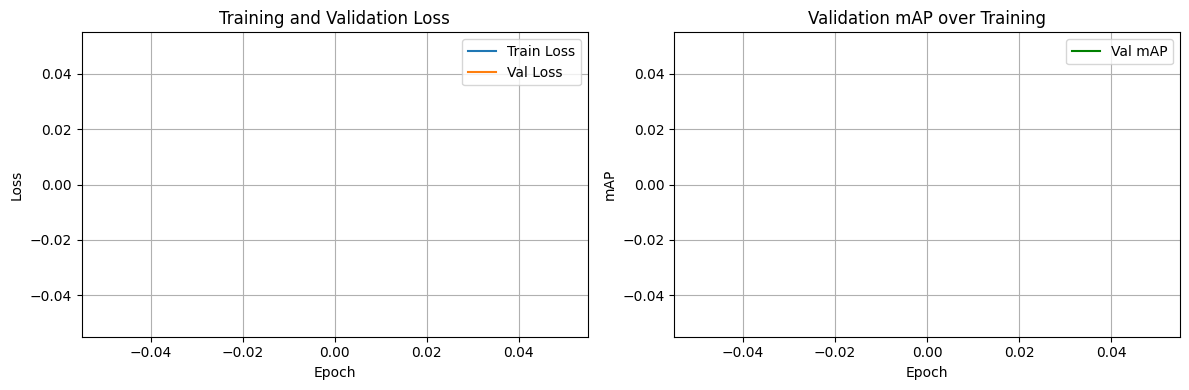

In [15]:
epochs_ran = range(1, len(history['train_loss']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Figure 1: Loss curves
ax1.plot(epochs_ran, history['train_loss'], label='Train Loss')
ax1.plot(epochs_ran, history['val_loss'],   label='Val Loss')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Training and Validation Loss')
ax1.legend()
ax1.grid(True)

# Figure 2: mAP curve
ax2.plot(epochs_ran, history['map'], label='Val mAP', color='green')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('mAP')
ax2.set_title('Validation mAP over Training')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()

In [13]:
# Run evaluation
all_preds, all_labels, all_probs = evaluate_metrics(val_loader)
_ = compute_all_metrics(all_labels, all_probs)

F1 Micro (tuned): 0.5449  |  F1 Macro (tuned): 0.3784
mAP:    0.352  (paper CRNN: 0.417, VGG-like: 0.434)
d':     2.146         (paper CRNN: 2.068, VGG-like: 2.167)
lωlrap: 0.636  (paper CRNN: 0.519, VGG-like: 0.514)
mAP (6 families): 0.6460
